# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [4]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [5]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [7]:
import os, zipfile, urllib.request

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")

Dataset downloaded and extracted.


## 4. Load the Data


In [14]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1
    # <-- Enter your code here <--#
    X_train = np.loadtxt(f"{root_dir}/train/X_train.txt")
    y_train = np.loadtxt(f"{root_dir}/train/y_train.txt", dtype=int)
    X_test  = np.loadtxt(f"{root_dir}/test/X_test.txt")
    y_test  = np.loadtxt(f"{root_dir}/test/y_test.txt", dtype=int)
    y_train -= 1
    y_test  -= 1
    return X_train, y_train, X_test, y_test
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes  = len(class_names)

## 5. Quick Inspection


In [15]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#
import pandas as pd

summary = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": [np.sum(y_train == i) for i in range(num_classes)]
})

print(summary.to_string(index=False))

 Class Index         Class Name  Training Samples
           0            WALKING              1226
           1   WALKING_UPSTAIRS              1073
           2 WALKING_DOWNSTAIRS               986
           3            SITTING              1286
           4           STANDING              1374
           5             LAYING              1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [17]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64,  activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
    raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [18]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - 0s 2ms/step - loss: 0.4751 - accuracy: 0.8065 - val_loss: 0.2229 - val_accuracy: 0.9225
Epoch 2/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1756 - accuracy: 0.9332 - val_loss: 0.1575 - val_accuracy: 0.9313
Epoch 3/40
92/92 [==============================] - 0s 1ms/step - loss: 0.1145 - accuracy: 0.9544 - val_loss: 0.4585 - val_accuracy: 0.8634
Epoch 4/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0981 - accuracy: 0.9607 - val_loss: 0.1532 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0853 - accuracy: 0.9680 - val_loss: 0.1937 - val_accuracy: 0.9286
Epoch 6/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0713 - accuracy: 0.9728 - val_loss: 0.2328 - val_accuracy: 0.9232
Epoch 7/40
92/92 [==============================] - 0s 1ms/step - loss: 0.0568 - accuracy: 0.9777 - val_loss: 0.1478 - val_accuracy: 0.9429
Epoch 8/40
92/92 [==

### Training Curves


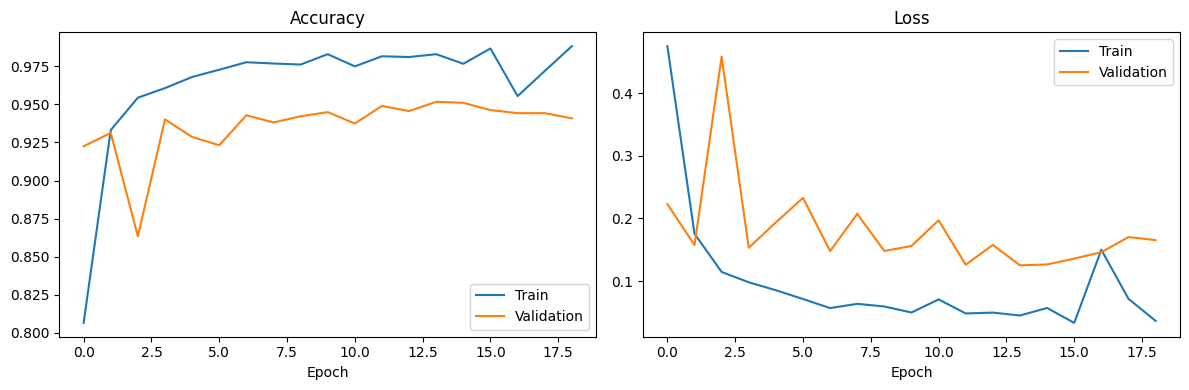

In [19]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(baseline_history.history['accuracy'], label='Train')
ax1.plot(baseline_history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(baseline_history.history['loss'], label='Train')
ax2.plot(baseline_history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 915us/step
Test Accuracy: 0.9223

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.93      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.89      0.92       471
WALKING_DOWNSTAIRS       0.89      0.94      0.91       420
           SITTING       0.89      0.92      0.90       491
          STANDING       0.88      0.89      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



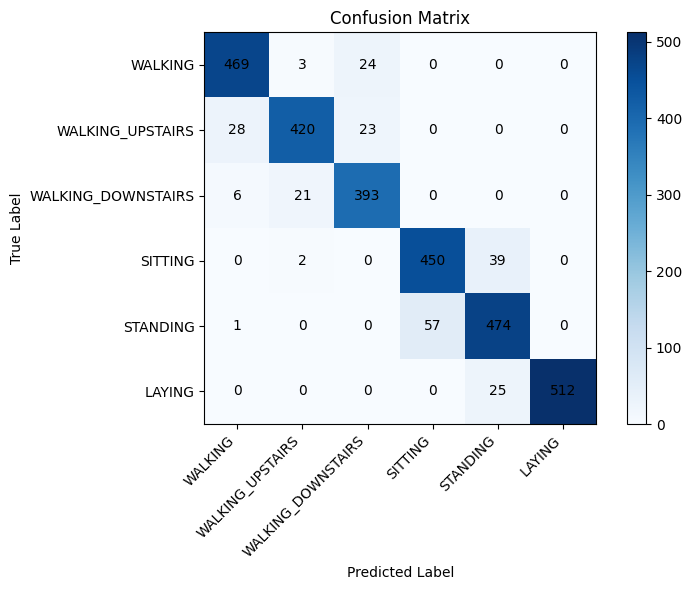

In [22]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [27]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    # <-- Enter your code here <--#
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]
    y_pred = []
    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)
        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        # <-- Enter your code here <--#
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = (x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])
        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])
        # TODO:
        # If the output is quantized, dequantize it back to float32.
        # <-- Enter your code here <--#
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        y_pred.append(np.argmax(output, axis=1)[0])
    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model
    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model
    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [28]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
tflite_fp16 = convert_to_tflite_float16(baseline_model)
tflite_int8 = convert_to_tflite_int8(baseline_model)

size_fp32 = save_binary_model(tflite_fp32, "model_fp32.tflite")
size_dynamic = save_binary_model(tflite_dynamic, "model_dynamic.tflite")
size_fp16 = save_binary_model(tflite_fp16, "model_fp16.tflite")
size_int8 = save_binary_model(tflite_int8, "model_int8.tflite")

acc_fp32, _ = evaluate_tflite_model(tflite_fp32, X_test, y_test)
acc_dynamic, _ = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
acc_fp16, _ = evaluate_tflite_model(tflite_fp16, X_test, y_test)
acc_int8, _ = evaluate_tflite_model(tflite_int8, X_test, y_test)

print(f"FP32    - Size: {size_fp32:.1f} KB, Accuracy: {acc_fp32:.4f}")
print(f"Dynamic - Size: {size_dynamic:.1f} KB, Accuracy: {acc_dynamic:.4f}")
print(f"Float16 - Size: {size_fp16:.1f} KB, Accuracy: {acc_fp16:.4f}")
print(f"Int8    - Size: {size_int8:.1f} KB, Accuracy: {acc_int8:.4f}")

INFO:tensorflow:Assets written to: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpd3n7iu2v/assets


INFO:tensorflow:Assets written to: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpd3n7iu2v/assets


INFO:tensorflow:Assets written to: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpyiwrpnrl/assets


2026-04-22 19:13:14.724844: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 19:13:14.724862: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 19:13:14.725005: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpd3n7iu2v
2026-04-22 19:13:14.725558: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 19:13:14.725564: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpd3n7iu2v
2026-04-22 19:13:14.727315: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 19:13:14.755983: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpd3n7iu2v
2026-04-

INFO:tensorflow:Assets written to: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmp54i12c_c/assets


2026-04-22 19:13:15.100717: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 19:13:15.100741: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 19:13:15.100893: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpyiwrpnrl
2026-04-22 19:13:15.101518: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 19:13:15.101524: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpyiwrpnrl
2026-04-22 19:13:15.103240: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 19:13:15.132036: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpyiwrpnrl
2026-04-

INFO:tensorflow:Assets written to: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmp6advh6u_/assets


2026-04-22 19:13:15.486241: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 19:13:15.486263: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 19:13:15.486409: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmp54i12c_c
2026-04-22 19:13:15.487037: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 19:13:15.487044: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmp54i12c_c
2026-04-22 19:13:15.488763: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 19:13:15.517439: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmp54i12c_c
2026-04-

FP32    - Size: 726.8 KB, Accuracy: 0.9223
Dynamic - Size: 186.2 KB, Accuracy: 0.9226
Float16 - Size: 365.8 KB, Accuracy: 0.9223
Int8    - Size: 185.4 KB, Accuracy: 0.9216


## 10. PTQ Comparison: Accuracy and Model Size


In [29]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
comparison_df = pd.DataFrame({
    "Model Family": ["Baseline", "Baseline", "Baseline", "Baseline"],
    "Format": ["FP32", "Dynamic Range", "Float16", "Int8"],
    "Test Accuracy": [acc_fp32, acc_dynamic, acc_fp16, acc_int8],
    "Model Size (KB)": [size_fp32, size_dynamic, size_fp16, size_int8]
})
print(comparison_df.to_string(index=False))

Model Family        Format  Test Accuracy  Model Size (KB)
    Baseline          FP32       0.922294       726.761719
    Baseline Dynamic Range       0.922633       186.156250
    Baseline       Float16       0.922294       365.785156
    Baseline          Int8       0.921615       185.359375


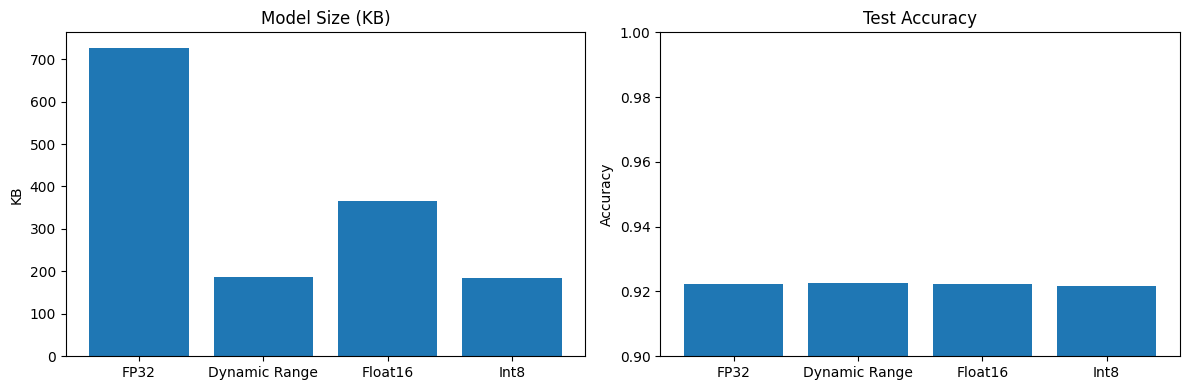

In [30]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(comparison_df["Format"], comparison_df["Model Size (KB)"])
ax1.set_title("Model Size (KB)")
ax1.set_ylabel("KB")

ax2.bar(comparison_df["Format"], comparison_df["Test Accuracy"])
ax2.set_title("Test Accuracy")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.9, 1.0)

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


                    precision    recall  f1-score   support

           WALKING       0.93      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.89      0.92       471
WALKING_DOWNSTAIRS       0.90      0.94      0.92       420
           SITTING       0.88      0.92      0.90       491
          STANDING       0.88      0.88      0.88       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



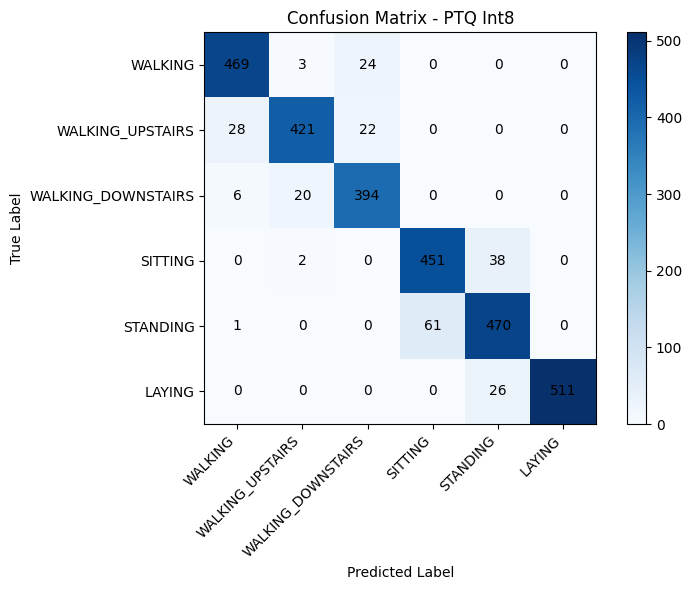

In [31]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
_, y_pred_int8 = evaluate_tflite_model(tflite_int8, X_test, y_test)

print(classification_report(y_test, y_pred_int8, target_names=class_names))

cm_int8 = confusion_matrix(y_test, y_pred_int8)
plt.figure(figsize=(8, 6))
plt.imshow(cm_int8, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix - PTQ Int8')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_int8[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [32]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
import tensorflow_model_optimization as tfmot

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)
qat_model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
qat_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense_4 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_5 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_6 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_7 (QuantizeWra  (None, 6)                

### Fine-Tune the QAT Model


In [33]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
92/92 [==============================] - 1s 3ms/step - loss: 0.0604 - accuracy: 0.9815 - val_loss: 0.1153 - val_accuracy: 0.9572
Epoch 2/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0330 - accuracy: 0.9898 - val_loss: 0.1215 - val_accuracy: 0.9551
Epoch 3/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0316 - accuracy: 0.9896 - val_loss: 0.1246 - val_accuracy: 0.9572
Epoch 4/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0273 - accuracy: 0.9898 - val_loss: 0.1243 - val_accuracy: 0.9558
Epoch 5/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0265 - accuracy: 0.9912 - val_loss: 0.1617 - val_accuracy: 0.9470
Epoch 6/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0283 - accuracy: 0.9896 - val_loss: 0.1438 - val_accuracy: 0.9551
Epoch 7/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0257 - accuracy: 0.9913 - val_loss: 0.1376 - val_accuracy: 0.9558
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [34]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
y_prob_qat = qat_model.predict(X_test)
y_pred_qat = np.argmax(y_prob_qat, axis=1)

test_acc_qat = accuracy_score(y_test, y_pred_qat)
print(f"QAT Keras Test Accuracy: {test_acc_qat:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_qat, target_names=class_names))

93/93 [==============================] - 0s 743us/step
QAT Keras Test Accuracy: 0.9345

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.93      0.96      0.95       496
  WALKING_UPSTAIRS       0.94      0.92      0.93       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.86      0.96      0.91       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [35]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
tflite_qat_int8 = convert_to_tflite_int8(qat_model)
size_qat_int8 = save_binary_model(tflite_qat_int8, "model_qat_int8.tflite")
acc_qat_int8, _ = evaluate_tflite_model(tflite_qat_int8, X_test, y_test)

print(f"QAT Int8 - Size: {size_qat_int8:.1f} KB, Accuracy: {acc_qat_int8:.4f}")

INFO:tensorflow:Assets written to: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpg1zpvbwi/assets


INFO:tensorflow:Assets written to: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpg1zpvbwi/assets


QAT Int8 - Size: 185.8 KB, Accuracy: 0.9338


/Users/kenziekosatria/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-22 19:16:32.297818: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 19:16:32.297846: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 19:16:32.298001: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpg1zpvbwi
2026-04-22 19:16:32.299417: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 19:16:32.299427: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/4z/xxm1j2r5595bdz9tc9gky9t40000gn/T/tmpg1zpvbwi
2026-04-22 19:16:32.303528: I tensorflow/cc/saved_model/loader.c

## 12. PTQ Int8 vs QAT Int8


In [36]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
ptq_vs_qat_df = pd.DataFrame({
    "Model": ["PTQ Int8", "QAT Int8"],
    "Test Accuracy": [acc_int8, acc_qat_int8],
    "Model Size (KB)": [size_int8, size_qat_int8]
})
print(ptq_vs_qat_df.to_string(index=False))

   Model  Test Accuracy  Model Size (KB)
PTQ Int8       0.921615       185.359375
QAT Int8       0.933831       185.781250


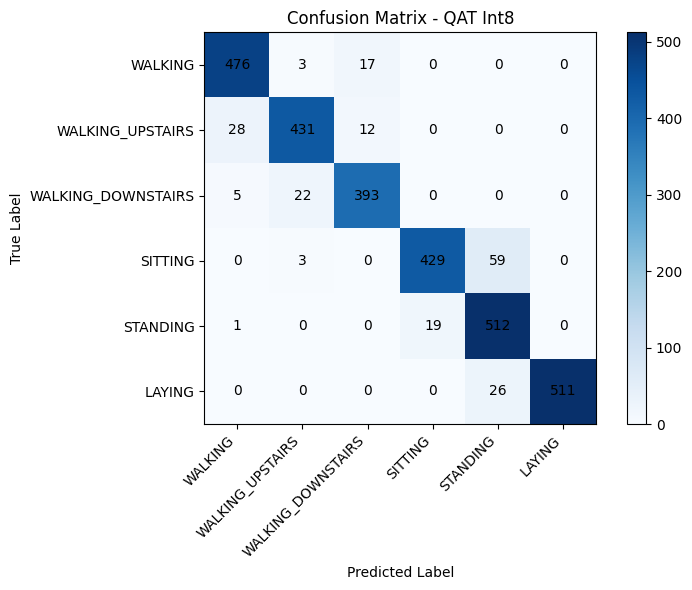

In [37]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
_, y_pred_qat_int8 = evaluate_tflite_model(tflite_qat_int8, X_test, y_test)

cm_qat = confusion_matrix(y_test, y_pred_qat_int8)
plt.figure(figsize=(8, 6))
plt.imshow(cm_qat, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix - QAT Int8')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm_qat[i, j], ha='center', va='center')
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
   
Answers:
1. PTQ Int8.
2. QAT Int8
3. yes it did from 92.6% to 93.8%.
4. Because it can directly learn from these features, making it computationally simple and uses a smaller memory and faster inference
5. QAT int 8 where it has a better accuracy and it's the smallest model size.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
